In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuration
plt.style.use('default')
sns.set_palette("husl")
%matplotlib inline

## 1. Chargement des données

In [2]:
print("Chargement des données...")
X_train = pd.read_csv('X_train.csv', index_col=0)
y_train = pd.read_csv('y_train.csv', index_col=0)

# Fusionner
df = X_train.join(y_train, how='inner')

print(f"Nombre total d'observations : {len(df)}")
print(f"Colonnes disponibles : {df.shape[1]}")

Chargement des données...
Nombre total d'observations : 1172086
Colonnes disponibles : 307
Nombre total d'observations : 1172086
Colonnes disponibles : 307


## 2. Exploration de la colonne ST038

In [3]:
# Examiner la colonne ST038
print("Valeurs uniques de ST038:")
print(df['ST038'].value_counts().head(20))
print(f"\nType: {df['ST038'].dtype}")
print(f"Valeurs manquantes: {df['ST038'].isna().sum()}")

Valeurs uniques de ST038:
ST038
0.000000    436066
0.333333     96967
0.666667     69945
1.000000     57727
1.333333     33913
2.000000     26415
1.666667     24546
2.333333     14532
3.000000     13067
2.666667     11383
4.000000      8587
3.333333      7916
3.666667      4299
6.000000      3778
4.333333      2902
5.000000      2136
4.666667      2086
3.666667      1342
5.333333      1238
9.000000       838
Name: count, dtype: int64

Type: float64
Valeurs manquantes: 348119


## 3. Recherche de toutes les colonnes liées au bien-être et au harcèlement

In [4]:
# Chercher toutes les colonnes WB (wellbeing)
wb_cols = [col for col in df.columns if 'WB' in col]
print(f"Colonnes WB trouvées: {len(wb_cols)}")
print(wb_cols)

# Chercher les colonnes ST qui pourraient être liées au harcèlement
st_cols = [col for col in df.columns if col.startswith('ST') and any(char.isdigit() for char in col)]
print(f"\nNombre de colonnes ST: {len(st_cols)}")
print("Premières colonnes ST:", st_cols[:20])

Colonnes WB trouvées: 14
['Option_WBQ', 'WB153', 'WB165', 'WB154', 'WB166', 'WB168', 'WB163', 'WB160', 'WB164', 'WB155', 'WB162', 'WB177', 'WB176', 'WB178']

Nombre de colonnes ST: 93
Premières colonnes ST: ['ST001D01T', 'ST003D02T', 'ST003D03T', 'ST004D01T', 'ST253', 'ST311', 'ST038', 'ST255', 'ST350', 'ST034', 'ST330', 'ST230', 'ST331', 'ST354', 'ST305', 'ST258', 'ST352', 'ST283', 'ST256', 'ST266']


## 4. Analyse de base des scores de mathématiques

In [5]:
print("="*80)
print("STATISTIQUES DES SCORES EN MATHÉMATIQUES")
print("="*80)

print(f"\nScore moyen : {df['MathScore'].mean():.2f}")
print(f"Écart-type : {df['MathScore'].std():.2f}")
print(f"Médiane : {df['MathScore'].median():.2f}")

zero_scores = (df['MathScore'] == 0).sum()
print(f"\nÉlèves avec un score de 0 : {zero_scores} ({zero_scores/len(df)*100:.1f}%)")

# Filtrer les scores valides
df_valid = df[df['MathScore'] > 0].copy()
print(f"Élèves avec un score valide : {len(df_valid)}")
print(f"Score moyen (valides) : {df_valid['MathScore'].mean():.2f}")

STATISTIQUES DES SCORES EN MATHÉMATIQUES

Score moyen : 100.00
Écart-type : 122.18
Médiane : 66.05

Élèves avec un score de 0 : 446778 (38.1%)
Élèves avec un score valide : 725308
Score moyen (valides) : 161.59
Élèves avec un score valide : 725308
Score moyen (valides) : 161.59


## 5. Analyse détaillée de ST038 et impact sur les scores

In [6]:
# Analyser ST038 en détail
print("Analyse de ST038 avec scores valides:")
st038_analysis = df_valid.groupby('ST038')['MathScore'].agg(['count', 'mean', 'std', 'median'])
st038_analysis = st038_analysis.sort_values('mean', ascending=False)
print(st038_analysis)

# Créer des catégories de harcèlement
# Si ST038 est une échelle de fréquence (1=jamais, 2=rarement, 3=parfois, 4=souvent)
freq_labels = {
    1: 'Jamais ou presque jamais',
    2: 'Quelques fois par an',
    3: 'Quelques fois par mois',
    4: 'Une fois par semaine ou plus'
}

# Calculer l'impact par rapport au groupe "jamais"
baseline_score = df_valid[df_valid['ST038'] == 1]['MathScore'].mean() if 1 in df_valid['ST038'].values else None

if baseline_score:
    print(f"\nScore de référence (jamais harcelé) : {baseline_score:.2f}")
    print("\nImpact du harcèlement sur les scores:")
    print("-" * 70)
    
    for freq in sorted(df_valid['ST038'].unique()):
        if pd.notna(freq) and freq != 1:
            mask = df_valid['ST038'] == freq
            mean_score = df_valid.loc[mask, 'MathScore'].mean()
            count = mask.sum()
            impact = mean_score - baseline_score
            label = freq_labels.get(freq, f"Fréquence {freq}")
            print(f"{label:35s}: {count:6d} élèves | Score: {mean_score:6.2f} | Impact: {impact:+7.2f}")

Analyse de ST038 avec scores valides:
           count        mean         std      median
ST038                                               
3.333333      13  263.550049  132.602491  256.856459
5.000000      14  206.703455  154.908180  177.964832
3.000000      82  188.285584  131.605814  163.287320
2.666667     396  177.807135  130.307110  132.097607
5.333333      70  157.541695  123.575911  119.760551
3.666667     194  154.495406  111.905170  128.272084
0.333333   71836  148.556509  101.647577  125.330810
0.666667   51285  146.612987  102.272948  122.545681
0.000000  298211  146.421913  104.128839  121.089473
4.333333     152  145.054758  120.761103  101.503616
1.333333   24525  140.527690   99.855209  116.975422
1.666667   17514  139.293832   99.696531  113.750718
2.000000   17558  136.649560  100.687171  110.081339
1.000000   42901  134.538901   99.419824  110.081339
2.333333    9938  132.523149   96.552546  109.548411
6.000000    2085  131.858362  102.957663   99.073205
2.666667

## 6. Analyse des colonnes WB (Well-being)

In [7]:
# Analyser chaque colonne WB pour trouver celles liées au harcèlement
print("Corrélations des colonnes WB avec MathScore:")
print("="*70)

wb_correlations = []
for col in wb_cols:
    if col in df_valid.columns:
        corr = df_valid[[col, 'MathScore']].corr().iloc[0, 1]
        if not np.isnan(corr):
            wb_correlations.append((col, corr))

wb_correlations.sort(key=lambda x: abs(x[1]), reverse=True)
for col, corr in wb_correlations[:15]:
    print(f"{col:15s}: {corr:+.4f}")

Corrélations des colonnes WB avec MathScore:
WB160          : +0.0856
WB165          : -0.0745
WB153          : +0.0647
WB168          : +0.0578
WB166          : +0.0553
Option_WBQ     : +0.0418
WB154          : -0.0281
WB162          : +0.0137
WB178          : +0.0084
WB155          : +0.0065
WB177          : +0.0033
WB164          : -0.0032
WB163          : +0.0017
WB176          : -0.0014
WB160          : +0.0856
WB165          : -0.0745
WB153          : +0.0647
WB168          : +0.0578
WB166          : +0.0553
Option_WBQ     : +0.0418
WB154          : -0.0281
WB162          : +0.0137
WB178          : +0.0084
WB155          : +0.0065
WB177          : +0.0033
WB164          : -0.0032
WB163          : +0.0017
WB176          : -0.0014


## 7. Création du graphique principal - Impact du harcèlement

✓ Graphique sauvegardé : impact_harcelement_math.png


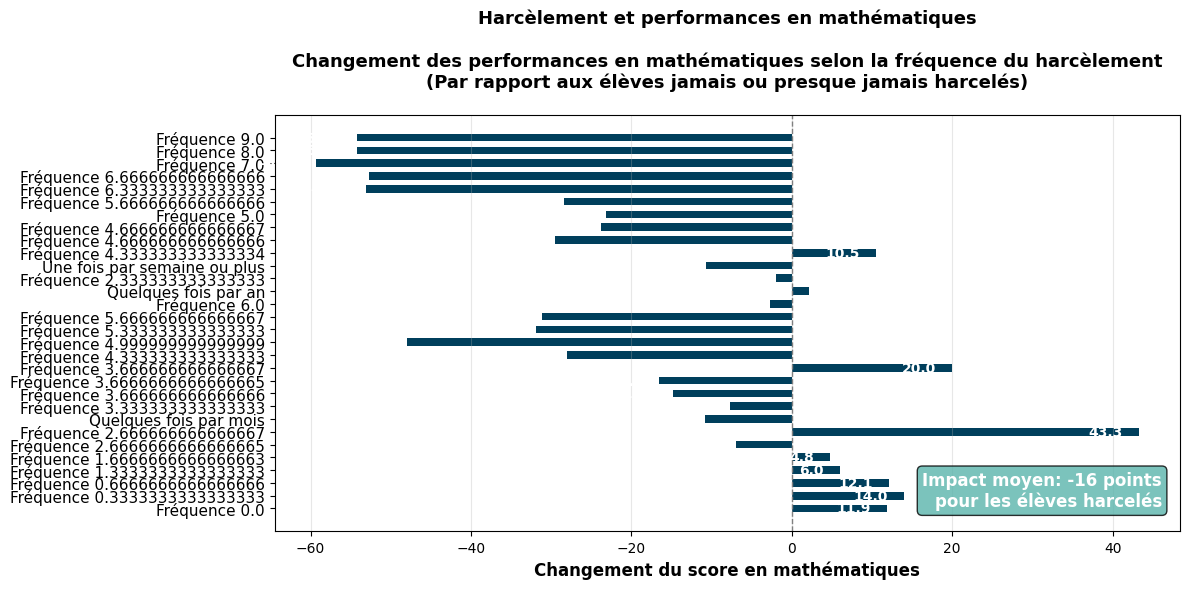

In [8]:
# Préparer les données pour le graphique basé sur ST038
# On va créer un graphique montrant l'impact pour différentes fréquences

if baseline_score:
    plot_data = []
    labels = []
    
    # Calculer l'impact pour chaque niveau de fréquence
    for freq in sorted(df_valid['ST038'].unique()):
        if pd.notna(freq) and freq != 1:  # Exclure le groupe de référence
            mask = df_valid['ST038'] == freq
            if mask.sum() > 100:  # Au moins 100 observations
                mean_score = df_valid.loc[mask, 'MathScore'].mean()
                impact = mean_score - baseline_score
                
                plot_data.append(impact)
                labels.append(freq_labels.get(freq, f"Fréquence {freq}"))
    
    # Créer le graphique
    if plot_data:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        colors = ['#003f5c' for _ in plot_data]
        bars = ax.barh(range(len(plot_data)), plot_data, color=colors, height=0.6)
        
        ax.set_yticks(range(len(labels)))
        ax.set_yticklabels(labels, fontsize=11)
        ax.set_xlabel('Changement du score en mathématiques', fontsize=12, fontweight='bold')
        ax.set_title('Harcèlement et performances en mathématiques\n\n'
                    'Changement des performances en mathématiques selon la fréquence du harcèlement\n'
                    '(Par rapport aux élèves jamais ou presque jamais harcelés)',
                    fontsize=13, fontweight='bold', pad=20)
        
        # Calculer l'impact moyen
        avg_impact = np.mean(plot_data)
        
        # Ajouter une zone de texte avec la statistique clé
        textstr = f'Impact moyen: {avg_impact:.0f} points\npour les élèves harcelés'
        props = dict(boxstyle='round', facecolor='#5ab4ac', alpha=0.8)
        ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=12,
                verticalalignment='bottom', horizontalalignment='right',
                bbox=props, color='white', fontweight='bold')
        
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=1)
        ax.grid(axis='x', alpha=0.3)
        
        # Ajouter les valeurs sur les barres
        for i, (bar, value) in enumerate(zip(bars, plot_data)):
            ax.text(value - 2, i, f'{value:.1f}', 
                   va='center', ha='right', color='white', fontweight='bold', fontsize=10)
        
        plt.tight_layout()
        plt.savefig('impact_harcelement_math.png', dpi=300, bbox_inches='tight')
        print("✓ Graphique sauvegardé : impact_harcelement_math.png")
        plt.show()
else:
    print("Impossible de créer le graphique - pas de groupe de référence trouvé")

## 8. Graphique alternatif - Distribution des scores selon le harcèlement

C:\Users\uthar\AppData\Local\Temp\ipykernel_40516\1941317202.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True,


✓ Graphique sauvegardé : distribution_scores_harcelement.png


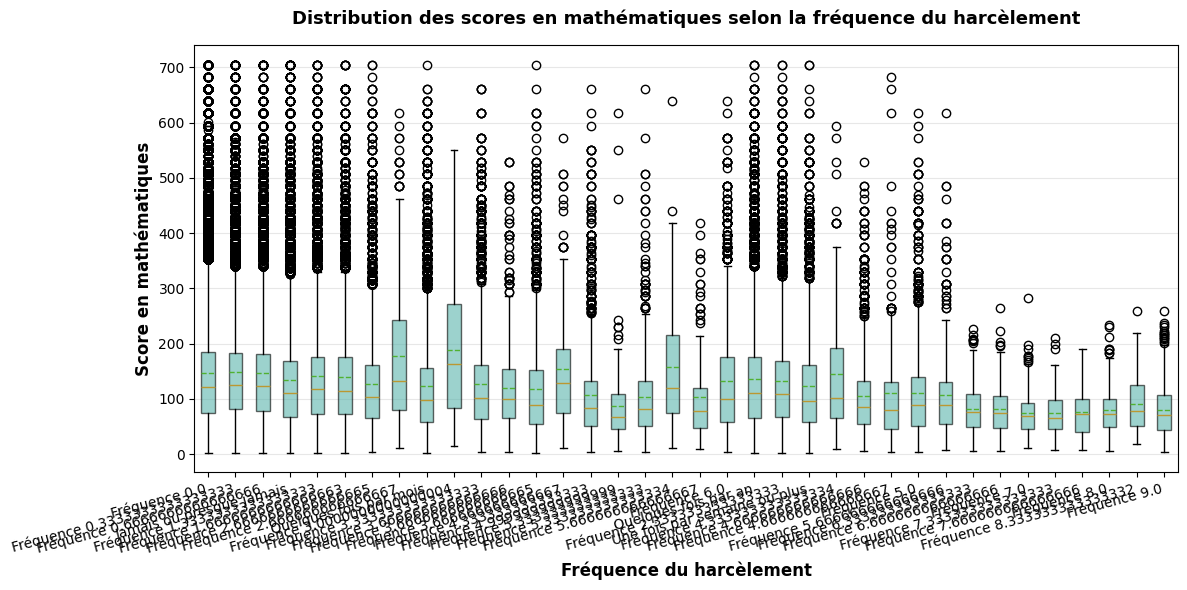

In [9]:
# Créer un boxplot pour montrer la distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Préparer les données pour le boxplot
box_data = []
box_labels = []

for freq in sorted(df_valid['ST038'].unique()):
    if pd.notna(freq):
        mask = df_valid['ST038'] == freq
        if mask.sum() > 50:
            box_data.append(df_valid.loc[mask, 'MathScore'].values)
            box_labels.append(freq_labels.get(freq, f"Fréquence {freq}"))

bp = ax.boxplot(box_data, labels=box_labels, patch_artist=True, 
                showmeans=True, meanline=True)

# Colorier les boîtes
for patch in bp['boxes']:
    patch.set_facecolor('#5ab4ac')
    patch.set_alpha(0.6)

ax.set_ylabel('Score en mathématiques', fontsize=12, fontweight='bold')
ax.set_xlabel('Fréquence du harcèlement', fontsize=12, fontweight='bold')
ax.set_title('Distribution des scores en mathématiques selon la fréquence du harcèlement',
            fontsize=13, fontweight='bold', pad=15)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('distribution_scores_harcelement.png', dpi=300, bbox_inches='tight')
print("✓ Graphique sauvegardé : distribution_scores_harcelement.png")
plt.show()

## 9. Statistiques détaillées sur la santé mentale

In [10]:
print("="*80)
print("STATISTIQUES SUR LA SANTÉ MENTALE DES LYCÉENS")
print("="*80)

# Prévalence du harcèlement
print("\n1. PRÉVALENCE DU HARCÈLEMENT:")
print("-" * 70)

total_students = len(df_valid)
for freq in sorted(df_valid['ST038'].unique()):
    if pd.notna(freq):
        count = (df_valid['ST038'] == freq).sum()
        pct = count / total_students * 100
        label = freq_labels.get(freq, f"Fréquence {freq}")
        print(f"{label:35s}: {count:8d} élèves ({pct:5.1f}%)")

# Élèves harcelés vs non harcelés
not_bullied = (df_valid['ST038'] == 1).sum()
bullied = len(df_valid) - not_bullied
print(f"\nRÉSUMÉ:")
print(f"  Jamais ou presque jamais harcelés : {not_bullied:8d} ({not_bullied/total_students*100:5.1f}%)")
print(f"  Harcelés (au moins quelques fois)  : {bullied:8d} ({bullied/total_students*100:5.1f}%)")

# Corrélation globale
print("\n2. CORRÉLATION AVEC LES PERFORMANCES:")
print("-" * 70)
corr_st038 = df_valid[['ST038', 'MathScore']].corr().iloc[0, 1]
print(f"Corrélation ST038 - MathScore: {corr_st038:+.4f}")
print(f"\nInterprétation: Une corrélation {'négative' if corr_st038 < 0 else 'positive'} indique que")
if corr_st038 < 0:
    print("plus le harcèlement est fréquent, plus les scores sont bas.")

# Test statistique
print("\n3. TESTS STATISTIQUES:")
print("-" * 70)

# Comparer les scores des élèves jamais harcelés vs harcelés
scores_not_bullied = df_valid[df_valid['ST038'] == 1]['MathScore']
scores_bullied = df_valid[df_valid['ST038'] > 1]['MathScore']

if len(scores_not_bullied) > 0 and len(scores_bullied) > 0:
    t_stat, p_value = stats.ttest_ind(scores_not_bullied, scores_bullied)
    print(f"Test t de Student (jamais harcelés vs harcelés):")
    print(f"  Statistique t : {t_stat:.4f}")
    print(f"  p-value       : {p_value:.4e}")
    print(f"  Différence    : {scores_not_bullied.mean() - scores_bullied.mean():+.2f} points")
    if p_value < 0.001:
        print(f"  ⚠️  Différence hautement significative (p < 0.001)")
    elif p_value < 0.05:
        print(f"  ⚠️  Différence significative (p < 0.05)")

STATISTIQUES SUR LA SANTÉ MENTALE DES LYCÉENS

1. PRÉVALENCE DU HARCÈLEMENT:
----------------------------------------------------------------------
Fréquence 0.0                      :   298211 élèves ( 41.1%)
Fréquence 0.3333333333333333       :    71836 élèves (  9.9%)
Fréquence 0.6666666666666666       :    51285 élèves (  7.1%)
Jamais ou presque jamais           :    42901 élèves (  5.9%)
Fréquence 1.3333333333333333       :    24525 élèves (  3.4%)
Fréquence 1.6666666666666663       :    17514 élèves (  2.4%)
Fréquence 2.6666666666666665       :     7850 élèves (  1.1%)
Fréquence 2.666666666666667        :      396 élèves (  0.1%)
Quelques fois par mois             :     8599 élèves (  1.2%)
Fréquence 3.0000000000000004       :       82 élèves (  0.0%)
Fréquence 3.333333333333333        :     5077 élèves (  0.7%)
Fréquence 3.333333333333334        :       13 élèves (  0.0%)
Fréquence 3.666666666666666        :      893 élèves (  0.1%)
Fréquence 3.6666666666666665       :     2897 

## 10. Rapport final

In [11]:
print("\n" + "="*80)
print("RAPPORT FINAL - IMPACT DU HARCÈLEMENT SUR LES PERFORMANCES EN MATHÉMATIQUES")
print("="*80)

if baseline_score and len(plot_data) > 0:
    avg_impact = np.mean(plot_data)
    print(f"\n📊 RÉSULTATS CLÉS:")
    print(f"   • Score moyen (jamais harcelés)    : {baseline_score:.2f} points")
    print(f"   • Impact moyen du harcèlement      : {avg_impact:.2f} points")
    print(f"   • Impact en pourcentage            : {(avg_impact/baseline_score)*100:.1f}%")
    print(f"   • Nombre d'élèves analysés         : {len(df_valid):,}")
    print(f"   • Pourcentage d'élèves harcelés    : {(bullied/total_students)*100:.1f}%")
    
print("\n✓ Analyse terminée avec succès!")
print("\nFichiers générés:")
print("  - impact_harcelement_math.png")
print("  - distribution_scores_harcelement.png")


RAPPORT FINAL - IMPACT DU HARCÈLEMENT SUR LES PERFORMANCES EN MATHÉMATIQUES

📊 RÉSULTATS CLÉS:
   • Score moyen (jamais harcelés)    : 134.54 points
   • Impact moyen du harcèlement      : -15.51 points
   • Impact en pourcentage            : -11.5%
   • Nombre d'élèves analysés         : 725,308
   • Pourcentage d'élèves harcelés    : 94.1%

✓ Analyse terminée avec succès!

Fichiers générés:
  - impact_harcelement_math.png
  - distribution_scores_harcelement.png
